In [15]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

In [16]:
N_data = 500
data = np.load(f"data/linear_advection_dataset_N_{N_data}.npz", allow_pickle=True)

input_data = data["u0"]
output_data = data["u"]
discon_x_data = data["discontinuities"]
x = data["x"]
t_domain = data["t"]

train_idx = data["train_idx"],
val_idx = data["val_idx"],
test_idx = data["test_idx"]

N, Nx, Nt = input_data.shape[0], x.shape[0], t_domain.shape[0]

## Cut-DeepONet

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class Cut_DeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=3, latent_dim=128, hidden_dim=256, depth=3):
        super().__init__()
        self.branch = MLP(branch_in, hidden_dim, latent_dim, depth=depth)
        self.trunk = MLP(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, lifted_trunk_input):
        # branch_input: (B, Nx), lifted_trunk_input: (B, P, 2)
        b = self.branch(branch_input)      # (B, latent)
        # Trunk with lifted domain input
        t = self.trunk(lifted_trunk_input)     # (B, P, latent)
        y = torch.einsum('bl,bpl->bp', b, t) + self.bias  # (B, P)
        return y

cut_deeponet = Cut_DeepONet(branch_in=Nx, latent_dim=128, hidden_dim=256, depth=3).to(device)

In [18]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[64, 64, 64]):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Rebuild and load model weights
checkpoint_path = "checkpoints/cutting_net_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

cutting_net = MLP(input_data.shape[1], discon_x_data.shape[1]*discon_x_data.shape[2]).to(device)
cutting_net.load_state_dict(checkpoint["model_state_dict"])
cutting_net.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=500, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=30, bias=True)
  )
)

In [19]:
def H(coords_np, discon_coords):
    discon_1 = discon_coords[:, 0]  # (Nt*Nx,)
    discon_2 = discon_coords[:, 1]  # (Nt*Nx,)
    x = coords_np[:, 0]
    return (x >= discon_1) & (x < discon_2)

def predict_full_field_cut_deeponet(model, x, t_domain, input_data_test, sample_idx, chunk = 20000):
    # full point for trunk network input
    xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
    coords_np = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

    # input for branch network
    input_test = torch.tensor(input_data_test[sample_idx:sample_idx+1], dtype=torch.float32, device=device)  # (1, Nx)

    # Predict discontinuity location & lifting
    discon_x_test = cutting_net(input_test).detach().cpu().numpy().reshape(Nt, 2).astype(np.float32)  # (Nt, 2)
    discon_coords = np.repeat(discon_x_test, Nx, axis=0)  # (Nt*Nx, 2)
    Hx = torch.as_tensor(H(coords_np, discon_coords), dtype=torch.float32, device=device)
    lifted_trunk_input_test = torch.cat(
        [torch.as_tensor(coords_np, dtype=torch.float32, device=device), Hx.unsqueeze(1)],
        dim=1,
    ).unsqueeze(0)  # (1, P, 3)

    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, coords_np.shape[0], chunk):
            lifted_trunk_batch = lifted_trunk_input_test[:, i:i+chunk, :].to(device)
            p = model(input_test, lifted_trunk_batch).squeeze(0).cpu().numpy()
            preds.append(p)
    pred_flat = np.concatenate(preds).reshape(Nt, Nx)

    return pred_flat, discon_x_test.squeeze()

def error_analysis_all_t(pred, true, xx, pred_discon, true_discon, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the discontinuity
    disc_idx_1 = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx][0])) for idx in range(xx.shape[0])])
    disc_idx_2 = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx][1])) for idx in range(xx.shape[0])])

    left_bound_1 = np.maximum(disc_idx_1 - window_size, 0)
    right_bound_1 = np.minimum(xx.shape[1], disc_idx_1 + window_size + 1)
    left_bound_2 = np.maximum(disc_idx_2 - window_size, 0)
    right_bound_2 = np.minimum(xx.shape[1], disc_idx_2 + window_size + 1)

    # l1_loss - remove the effect of twice the error for two parallel discontinuity
    pred_disc_idx_1 = np.array([np.argmin(np.abs(xx[idx, :] - pred_discon[idx][0])) for idx in range(xx.shape[0])])
    pred_disc_idx_2 = np.array([np.argmin(np.abs(xx[idx, :] - pred_discon[idx][1])) for idx in range(xx.shape[0])])
    error_between_discon_1 = np.mean([np.sum(abs_err[i, min(pred_disc_idx_1[i], disc_idx_1[i]):max(pred_disc_idx_1[i], disc_idx_1[i])+1]) for i in range(abs_err.shape[0])])
    error_between_discon_2 = np.mean([np.sum(abs_err[i, min(pred_disc_idx_2[i], disc_idx_2[i]):max(pred_disc_idx_2[i], disc_idx_2[i])+1]) for i in range(abs_err.shape[0])])
    l1_loss_fair = l1_loss - (error_between_discon_1 + error_between_discon_2) / (abs_err.shape[1] * 2)  # only get have error caused by the error between two parallel discontinuity

    # l1_loss_mean near discontinuity
    abs_err_near_dis_1 = np.array([np.mean(abs_err[i, left_bound_1[i]:right_bound_1[i]]) for i in range(abs_err.shape[0])])
    abs_err_near_dis_2 = np.array([np.mean(abs_err[i, left_bound_2[i]:right_bound_2[i]]) for i in range(abs_err.shape[0])])
    l1_loss_near_discon = np.mean(abs_err_near_dis_1) + np.mean(abs_err_near_dis_2)

    l1_loss_fair_near_discon = l1_loss_near_discon - (error_between_discon_1/abs_err_near_dis_1.shape[0] + error_between_discon_2/abs_err_near_dis_2.shape[0]) / 2  # only get have error caused by the error between two parallel discontinuity

    return l1_loss, l1_loss_near_discon, l1_loss_fair, l1_loss_fair_near_discon, left_bound_1, right_bound_1, left_bound_2, right_bound_2

def show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, sample_id):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)
    
    pred_field, pred_discon = predict_full_field_cut_deeponet(model, x_test, t_domain_test, input_data_test, sample_idx=sample_id, chunk=20000)
    true_field = output_data_test[sample_id]

    _, _, _, _, left_bound_1, right_bound_1, left_bound_2, right_bound_2 = error_analysis_all_t(pred_field, true_field, xx, pred_discon, discon_x_data_test[sample_id], window_size=int(0.05 * Nx))  # 5% of total points on each side of the discontinuity

    t_plot = 0.15
    t_idx = int(t_plot / (t_domain_test[1] - t_domain_test[0]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(x_test, input_data_test[sample_id], color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(x_test, pred_field[t_idx], color="red", label="Pred")
    axes[1].plot(x_test, true_field[t_idx], color="blue", linestyle="--", label="True")
    # axes[1].axvline(x=pred_discon[t_idx][0], color="purple", linestyle="--", alpha=0.5, label="Pred discontinuity")
    axes[1].axvline(x_test[left_bound_1[t_idx]], color="green", alpha=0.5, label="Discontinuity region")
    axes[1].axvline(x_test[right_bound_1[t_idx]], color="green", alpha=0.5)
    axes[1].axvline(x_test[left_bound_2[t_idx]], color="orange", alpha=0.5, label="Discontinuity region 2")
    axes[1].axvline(x_test[right_bound_2[t_idx]], color="orange", alpha=0.5)
    axes[1].set_title(f"t={t_domain_test[t_idx]:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

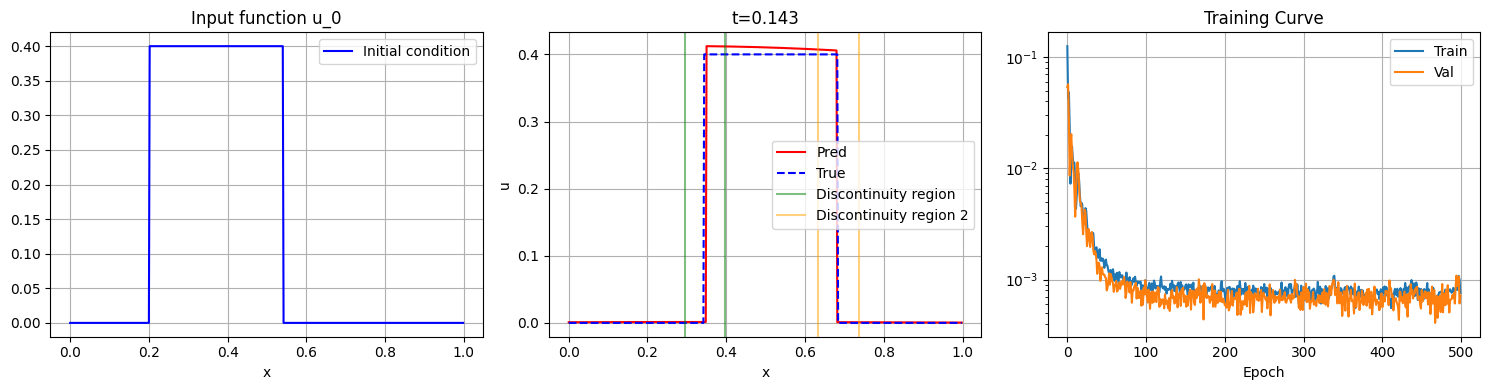

In [20]:
# Load the trained Lifted-DeepONet model
checkpoint = torch.load("checkpoints/cut_deeponet_checkpoint.pt", map_location=device, weights_only=False)
cut_deeponet.load_state_dict(checkpoint["model_state_dict"])
cut_deeponet.eval()

input_data_test, output_data_test, discon_x_data_test = input_data[test_idx], output_data[test_idx], discon_x_data[test_idx]

show_results(cut_deeponet, checkpoint, input_data_test, output_data_test, x, t_domain, discon_x_data_test, sample_id=1)

## DeepONet, flex-DeepOnet, Hyper-DeepONet

In [21]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=2, latent_dim=128, hidden_dim=256, depth=3):
        super().__init__()
        self.branch = MLP(branch_in, hidden_dim, latent_dim, depth=depth)
        self.trunk = MLP(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, trunk_input):
        # branch_input: (B, Nx), trunk_input: (P, 2)
        b = self.branch(branch_input)      # (B, latent)
        t = self.trunk(trunk_input)        # (P, latent)
        y = b @ t.T + self.bias            # (B, P)
        return y

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
deeponet = DeepONet(branch_in=Nx, latent_dim=128, hidden_dim=512, depth=3).to(device)

In [22]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class BranchNet(nn.Module):
    def __init__(self, in_dim, hidden_dim, latent_dim, depth=3):
        super().__init__()
        self.net = MLP(in_dim, hidden_dim, latent_dim + 1, depth=depth)

    def forward(self, u):
        out = self.net(u)                # (B, latent_dim + 1)
        coeffs = out[:, :-1]             # (B, latent_dim)
        shift = out[:, -1:]              # (B, 1)
        return coeffs, shift

class PreNet(nn.Module):
    def __init__(self, in_dim, hidden_dim, depth=3, use_scale=True):
        super().__init__()
        self.use_scale = use_scale
        out_dim = 3 if use_scale else 2   # [log_s, dx, dt] or just [dx, dt]
        self.net = MLP(in_dim, hidden_dim, out_dim, depth=depth)

    def forward(self, u):
        out = self.net(u)  # (B, out_dim)

        if self.use_scale:
            log_scale = out[:, 0:1]       # (B, 1)
            delta = out[:, 1:3]           # (B, 2)
            scale = torch.exp(log_scale)  # positive scale
        else:
            scale = None
            delta = out[:, 0:2]

        return scale, delta

class TrunkNet(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=256, latent_dim=128, depth=3):
        super().__init__()
        self.net = MLP(in_dim, hidden_dim, latent_dim, depth=depth)

    def forward(self, coords):
        B, P, D = coords.shape
        coords_flat = coords.reshape(B * P, D)
        out = self.net(coords_flat)              # (B*P, latent_dim)
        return out.reshape(B, P, -1)            # (B, P, latent_dim)

class FlexDeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=2, latent_dim=128, hidden_dim=256, depth=3, use_scale=True):
        super().__init__()
        self.branch = BranchNet(branch_in, hidden_dim, latent_dim, depth=depth)
        self.prenet = PreNet(branch_in, hidden_dim, depth=depth, use_scale=use_scale)
        self.trunk = TrunkNet(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def transform_coords(self, trunk_input, scale, delta):
        coords = trunk_input.unsqueeze(0)            # (1, P, 2)
        coords = scale.unsqueeze(1) * coords if scale is not None else coords.expand(delta.shape[0], -1, -1)  # (B, P, 2)
        coords = coords + delta.unsqueeze(1)         # (B, P, 2)
        return coords

    def forward(self, branch_input, trunk_input):
        coeffs, out_shift = self.branch(branch_input)    # (B, latent), (B, 1)
        scale, delta = self.prenet(branch_input)         # (B, 1), (B, 2) or None, (B, 2)

        coords_tilde = self.transform_coords(trunk_input, scale, delta)  # (B, P, 2)
        trunk_features = self.trunk(coords_tilde)                         # (B, P, latent)

        # sample-wise inner product
        y = torch.sum(coeffs.unsqueeze(1) * trunk_features, dim=-1)      # (B, P)
        y = y + out_shift + self.bias                                     # broadcast (B,1) over P
        return y

# ---------------------------
# 3) Instantiate model
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flex_deeponet = FlexDeepONet(branch_in=Nx, trunk_in=2, latent_dim=128, hidden_dim=256, depth=3, use_scale=True).to(device)

In [23]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class HyperNetwork(nn.Module):
    def __init__(self, branch_in, hidden_dim, param_dim, depth=3):
        super().__init__()
        self.net = MLP(branch_in, hidden_dim, param_dim, depth=depth)

    def forward(self, u):
        return self.net(u)   # (B, param_dim)

class TargetNetworkSpec:
    def __init__(self, layer_dims):
        self.layer_dims = layer_dims
        self.shapes = []
        self.param_dim = 0

        for in_dim, out_dim in zip(layer_dims[:-1], layer_dims[1:]):
            w_numel = out_dim * in_dim
            b_numel = out_dim
            self.shapes.append({
                "W_shape": (out_dim, in_dim),
                "b_shape": (out_dim,),
                "W_numel": w_numel,
                "b_numel": b_numel,
            })
            self.param_dim += w_numel + b_numel

    def unflatten(self, flat_params):
        B = flat_params.shape[0]
        params = []
        start = 0

        for spec in self.shapes:
            w_numel = spec["W_numel"]
            b_numel = spec["b_numel"]
            out_dim, in_dim = spec["W_shape"]

            W = flat_params[:, start:start + w_numel].reshape(B, out_dim, in_dim)
            start += w_numel

            b = flat_params[:, start:start + b_numel].reshape(B, out_dim)
            start += b_numel

            params.append((W, b))

        return params

class HyperDeepONet(nn.Module):
    def __init__(self, branch_in, target_layer_dims=(2, 64, 64, 1), hyper_hidden_dim=256, hyper_depth=3, activation=torch.tanh):
        super().__init__()

        self.target_spec = TargetNetworkSpec(list(target_layer_dims))
        self.hypernet = HyperNetwork(branch_in=branch_in, hidden_dim=hyper_hidden_dim, param_dim=self.target_spec.param_dim, depth=hyper_depth)
        self.activation = activation

    def forward(self, branch_input, trunk_input):
        B, P = branch_input.shape[0], trunk_input.shape[0]

        # Generate sample-specific target-network parameters
        flat_params = self.hypernet(branch_input)         # (B, param_dim)
        layer_params = self.target_spec.unflatten(flat_params)

        # Expand coordinates so each sample uses its own generated network
        h = trunk_input.unsqueeze(0).expand(B, P, -1)     # (B, P, 2)

        # Apply target network layer by layer
        num_layers = len(layer_params)
        for i, (W, b) in enumerate(layer_params):
            h = torch.einsum("bpi,boi->bpo", h, W) + b.unsqueeze(1)

            if i < num_layers - 1:
                h = self.activation(h)

        # final h: (B, P, 1)
        return h.squeeze(-1)   # (B, P)

# ---------------------------
# 3) Instantiate model
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hyper_deeponet = HyperDeepONet(branch_in=Nx,target_layer_dims=(2, 64, 64, 1), hyper_hidden_dim=150,hyper_depth=3).to(device)

In [24]:
def predict_full_field(model, x_func_np, coords_np, Nt, Nx, chunk=20000):
    preds = []
    x_func = torch.tensor(x_func_np[None, :], dtype=torch.float32, device=device)  # (1, Nx)
    with torch.no_grad():
        for i in range(0, coords_np.shape[0], chunk):
            c = torch.tensor(coords_np[i:i+chunk], dtype=torch.float32, device=device)
            p = model(x_func, c).squeeze(0).cpu().numpy()
            preds.append(p)

    return np.concatenate(preds).reshape(Nt, Nx)

def error_analysis_all_t(pred, true, xx, true_discon, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the discontinuity
    disc_idx_1 = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx][0])) for idx in range(xx.shape[0])])
    disc_idx_2 = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx][1])) for idx in range(xx.shape[0])])

    left_bound_1 = np.maximum(disc_idx_1 - window_size, 0)
    right_bound_1 = np.minimum(xx.shape[1], disc_idx_1 + window_size + 1)
    left_bound_2 = np.maximum(disc_idx_2 - window_size, 0)
    right_bound_2 = np.minimum(xx.shape[1], disc_idx_2 + window_size + 1)

    # l1_loss near discontinuity
    abs_err_near_dis_1 = np.array([np.mean(abs_err[i, left_bound_1[i]:right_bound_1[i]]) for i in range(abs_err.shape[0])])
    abs_err_near_dis_2 = np.array([np.mean(abs_err[i, left_bound_2[i]:right_bound_2[i]]) for i in range(abs_err.shape[0])])
    l1_loss_near_discon = np.mean(abs_err_near_dis_1) + np.mean(abs_err_near_dis_2)

    return l1_loss, l1_loss_near_discon, left_bound_1, right_bound_1, left_bound_2, right_bound_2

def error_analysis_dataset_test(model, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, window_size=5):
    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

    l1_loss_all, l1_loss_near_discon_all = [], []
    for sample_id in range(input_data_test.shape[0]):
        pred_field = predict_full_field(model, input_data_test[sample_id], coords_np_test, Nt, Nx, chunk=20000)

        l1_loss, l1_loss_near_discon, _, _, _, _ = error_analysis_all_t(pred_field, output_data_test[sample_id], xx, true_discon=discon_x_data_test[sample_id], window_size=window_size)  
        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)

    return l1_loss_all, l1_loss_near_discon_all

def show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, sample_id, title=""):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)
    
    pred_field = predict_full_field(model, input_data_test[sample_id], coords_np_test, Nt, Nx, chunk=20000)
    true_field = output_data_test[sample_id]

    _, _, left_bound_1, right_bound_1, left_bound_2, right_bound_2 = error_analysis_all_t(pred_field, true_field, xx, true_discon=discon_x_data_test[sample_id], window_size=int(0.05 * Nx))  # 5% of total points on each side of the discontinuity

    t_plot = 0.15
    t_idx = int(t_plot / (t_domain_test[1] - t_domain_test[0]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(x_test, input_data_test[sample_id], color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(x_test, pred_field[t_idx], color="red", label="Pred")
    axes[1].plot(x_test, true_field[t_idx], color="blue", linestyle="--", label="True")
    axes[1].axvline(x_test[left_bound_1[t_idx]], color="green", alpha=0.5, label="Discontinuity region")
    axes[1].axvline(x_test[right_bound_1[t_idx]], color="green", alpha=0.5)
    axes[1].axvline(x_test[left_bound_2[t_idx]], color="orange", alpha=0.5, label="Discontinuity region 2")
    axes[1].axvline(x_test[right_bound_2[t_idx]], color="orange", alpha=0.5)
    axes[1].set_title(f"t={t_domain_test[t_idx]:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)

    plt.title(title)
    plt.tight_layout()
    plt.show()

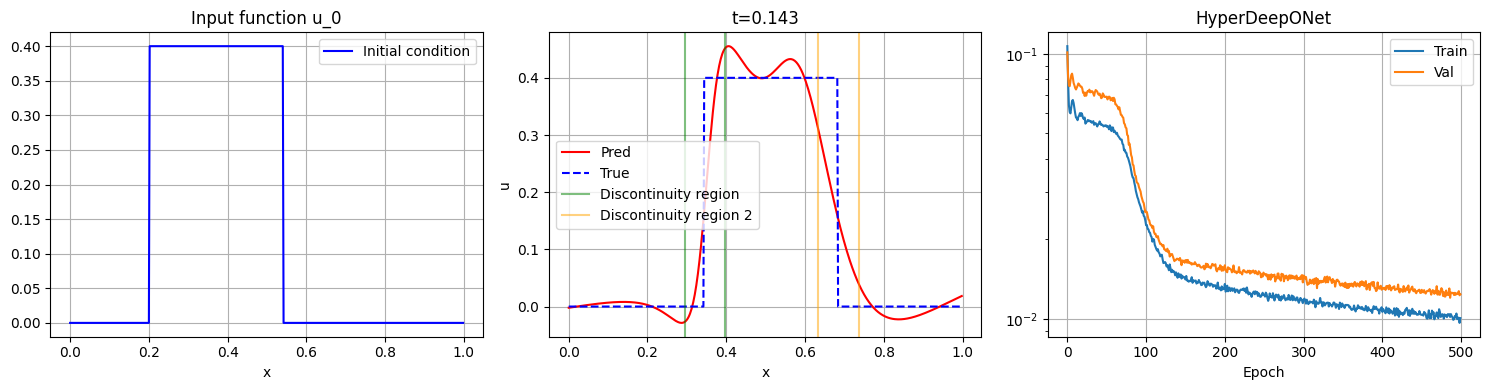

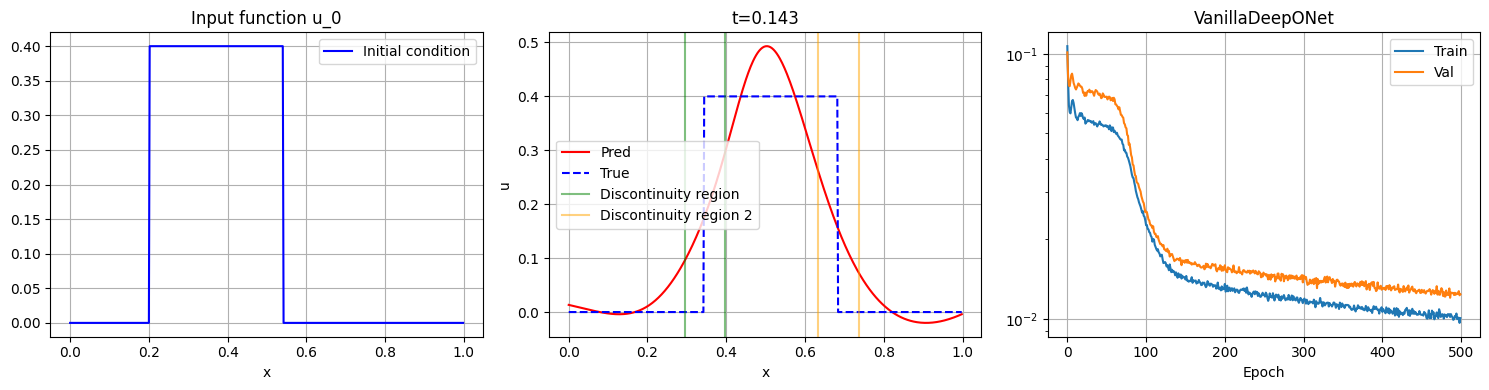

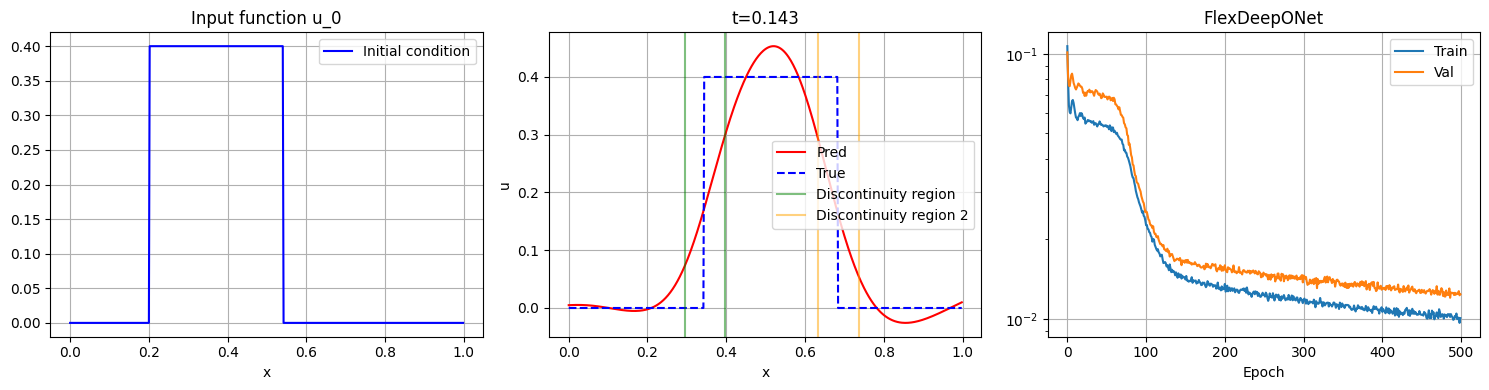

In [25]:
checkpoint = torch.load("checkpoints/hyper_deeponet_checkpoint.pt", map_location=device, weights_only=False)
hyper_deeponet.load_state_dict(checkpoint["model_state_dict"])
hyper_deeponet.eval()

checkpoint = torch.load("checkpoints/vanilla_deeponet_checkpoint.pt", map_location=device, weights_only=False)
deeponet.load_state_dict(checkpoint["model_state_dict"])
deeponet.eval()

checkpoint = torch.load("checkpoints/flex_deeponet_checkpoint.pt", map_location=device, weights_only=False)
flex_deeponet.load_state_dict(checkpoint["model_state_dict"])
flex_deeponet.eval()

input_data_test, output_data_test, discon_x_data_test = input_data[test_idx], output_data[test_idx], discon_x_data[test_idx]

show_results(hyper_deeponet, checkpoint, input_data_test, output_data_test, x, t_domain, discon_x_data_test, sample_id=1, title="HyperDeepONet")
show_results(deeponet, checkpoint, input_data_test, output_data_test, x, t_domain, discon_x_data_test, sample_id=1, title="VanillaDeepONet")
show_results(flex_deeponet, checkpoint, input_data_test, output_data_test, x, t_domain, discon_x_data_test, sample_id=1, title="FlexDeepONet")

## FNO

In [26]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        b, c, h, w = x.shape
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(b, self.out_channels, h, w // 2 + 1, dtype=torch.cfloat, device=x.device)

        m1 = min(self.modes1, h)
        m2 = min(self.modes2, w // 2 + 1)

        out_ft[:, :, :m1, :m2] = self.compl_mul2d(x_ft[:, :, :m1, :m2], self.weights1[:, :, :m1, :m2])
        out_ft[:, :, -m1:, :m2] = self.compl_mul2d(x_ft[:, :, -m1:, :m2], self.weights2[:, :, :m1, :m2])

        return torch.fft.irfft2(out_ft, s=(h, w))

class FNO2d(nn.Module):
    def __init__(self, in_channels=3, width=64, modes1=12, modes2=12):
        super().__init__()
        self.fc0 = nn.Linear(in_channels, width)

        self.conv0 = SpectralConv2d(width, width, modes1, modes2)
        self.conv1 = SpectralConv2d(width, width, modes1, modes2)
        self.conv2 = SpectralConv2d(width, width, modes1, modes2)
        self.conv3 = SpectralConv2d(width, width, modes1, modes2)

        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)
        self.w3 = nn.Conv2d(width, width, 1)

        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # x: (B, 3, Nt, Nx)
        x = x.permute(0, 2, 3, 1)      # (B, Nt, Nx, 3)
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)      # (B, width, Nt, Nx)

        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))

        x = x.permute(0, 2, 3, 1)      # (B, Nt, Nx, width)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x.permute(0, 3, 1, 2)   # (B, 1, Nt, Nx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fno = FNO2d(in_channels=3, width=64, modes1=12, modes2=12).to(device)

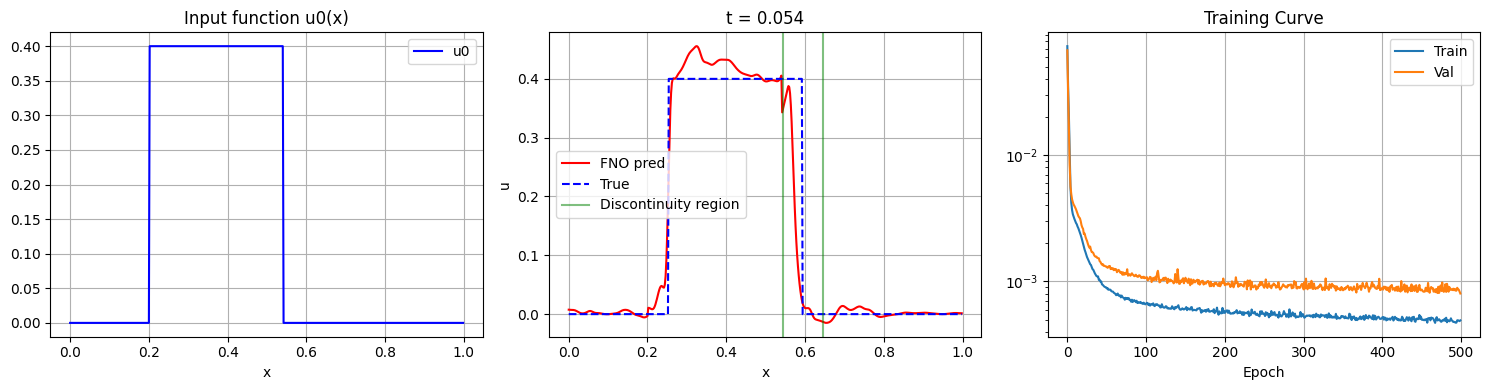

In [27]:

def predict_full_field_fno(model, x, t_domain, input_data_test, sample_idx):
    xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
    xx_b = np.broadcast_to(xx[None, None, :, :], (1, 1, Nt, Nx))
    tt_b = np.broadcast_to(tt[None, None, :, :], (1, 1, Nt, Nx))
    u0 = np.repeat(input_data_test[sample_idx:sample_idx+1].astype(np.float32)[:, None, None, :], Nt, axis=2)
    X_in = np.concatenate([u0, xx_b, tt_b], axis=1).astype(np.float32)

    with torch.no_grad():
        X_in = torch.from_numpy(X_in).to(device, dtype=torch.float32)
        pred_field = model(X_in).squeeze(0).squeeze(0).cpu().numpy()

    return pred_field

def show_results(model, checkpoint, input_data, output_data, x, t_domain, discon_x_data, sample_id):
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    # Pick one validation sample (original dataset index)
    X_sample, Y_sample = input_data[sample_id, :].astype(np.float32), output_data[sample_id, :].astype(np.float32)

    # Build FNO input for one sample: [u0(x), x, t] -> (1, 3, Nt, Nx)
    xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
    xx_b, tt_b = np.broadcast_to(xx[None, None, :, :], (1, 1, Nt, Nx)), np.broadcast_to(tt[None, None, :, :], (1, 1, Nt, Nx))  # (1, 1, Nt, Nx)
    u0 = np.repeat(X_sample[None, None, None, :], Nt, axis=2)              # (1, 1, Nt, Nx)
    X_in = np.concatenate([u0, xx_b, tt_b], axis=1)                        # (1, 3, Nt, Nx)

    # Predict
    with torch.no_grad():
        X_in = torch.from_numpy(X_in).to(device)
        pred_field = model(X_in).squeeze(0).squeeze(0).cpu().numpy()            # (Nt, Nx)

    # Error analysis
    discon_x_data = discon_x_data[sample_id]
    _, _, _, _, left_bound, right_bound = error_analysis_all_t(pred_field, Y_sample, xx, true_discon=discon_x_data, window_size=int(0.05 * Nx))  # 5% of total points on each side of the discontinuity

    # Plot at a chosen time
    t_plot = 0.07
    t_plot_idx = int(t_plot / (t_domain[1] - t_domain[0]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(x, X_sample, color="blue", label="u0")
    axes[0].set_title("Input function u0(x)")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(x, pred_field[t_plot_idx], color="red", label="FNO pred")
    axes[1].plot(x, Y_sample[t_plot_idx], color="blue", linestyle="--", label="True")
    axes[1].axvline(x[left_bound[t_plot_idx]], color='green', alpha=0.5, label="Discontinuity region")
    axes[1].axvline(x[right_bound[t_plot_idx]], color='green', alpha=0.5)
    axes[1].set_title(f"t = {t_domain[t_plot_idx]:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

checkpoint = torch.load("checkpoints/vanilla_fno_checkpoint.pt", map_location=device, weights_only=False)
fno.load_state_dict(checkpoint["model_state_dict"])
fno.eval()

show_results(fno, checkpoint, input_data_test, output_data_test, x, t_domain, discon_x_data_test, sample_id=1)

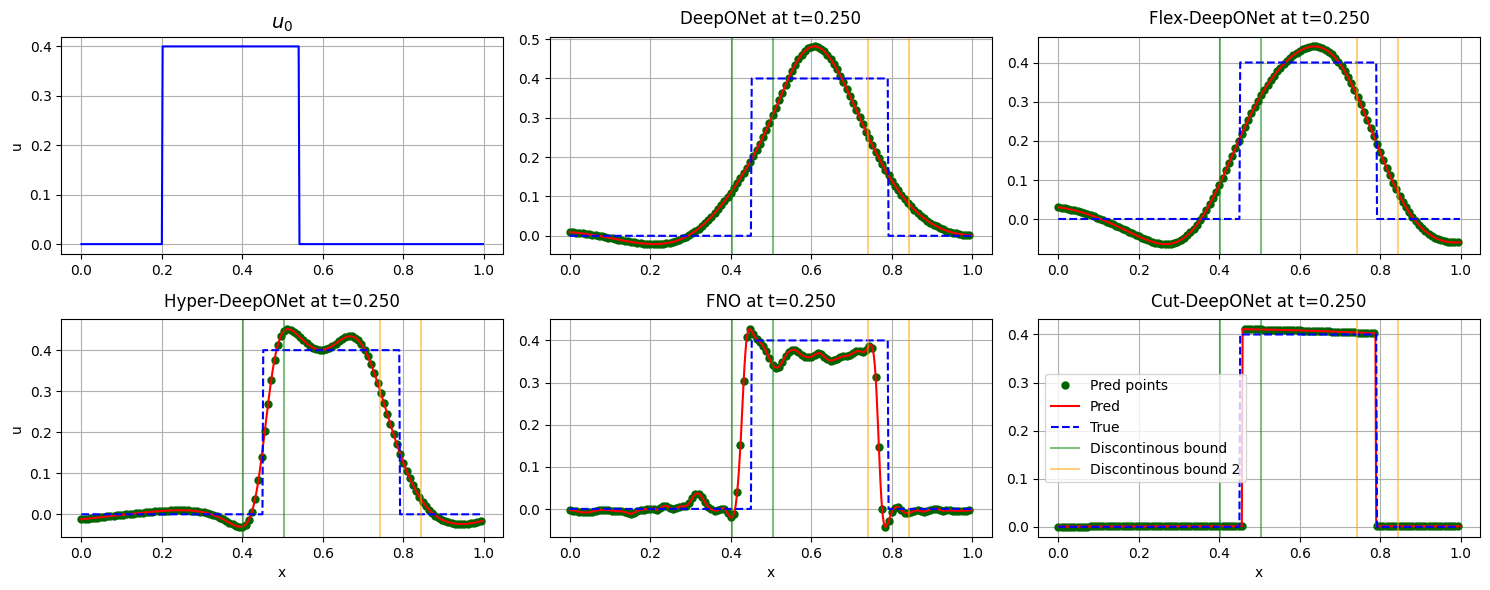

In [ ]:
def plotting_all_in_one(
    deeponet, flex_deeponet, hyper_deeponet, fno,
    input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test,
    sample_id, t_plot=0.07
):
    # Load checkpoints
    checkpoint_deeponet = torch.load("checkpoints/vanilla_deeponet_checkpoint.pt", map_location=device, weights_only=False)
    checkpoint_flex = torch.load("checkpoints/flex_deeponet_checkpoint.pt", map_location=device, weights_only=False)
    checkpoint_hyper = torch.load("checkpoints/hyper_deeponet_checkpoint.pt", map_location=device, weights_only=False)
    checkpoint_cut = torch.load("checkpoints/cut_deeponet_checkpoint.pt", map_location=device, weights_only=False)
    checkpoint_fno = torch.load("checkpoints/vanilla_fno_checkpoint.pt", map_location=device, weights_only=False)

    deeponet.load_state_dict(checkpoint_deeponet["model_state_dict"])
    flex_deeponet.load_state_dict(checkpoint_flex["model_state_dict"])
    hyper_deeponet.load_state_dict(checkpoint_hyper["model_state_dict"])
    cut_deeponet.load_state_dict(checkpoint_cut["model_state_dict"])
    fno.load_state_dict(checkpoint_fno["model_state_dict"])

    deeponet.eval()
    flex_deeponet.eval()
    hyper_deeponet.eval()
    cut_deeponet.eval()
    fno.eval()

    # Grid coords for DeepONet-style models
    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np = np.stack([xx, tt], axis=-1).reshape(-1, 2)

    pred_deeponet = predict_full_field(deeponet, input_data_test[sample_id], coords_np, Nt, Nx)
    pred_flex = predict_full_field(flex_deeponet, input_data_test[sample_id], coords_np, Nt, Nx)
    pred_hyper = predict_full_field(hyper_deeponet, input_data_test[sample_id], coords_np, Nt, Nx)
    pred_cut = predict_full_field_cut_deeponet(cut_deeponet, x_test, t_domain_test, input_data_test, sample_idx=sample_id)[0]
    pred_fno = predict_full_field_fno(fno, x_test, t_domain_test, input_data_test, sample_id)

    true_field = output_data_test[sample_id]

    # Safe time index
    t_plot_idx = int(np.argmin(np.abs(t_domain_test - t_plot)))

    disc_idx_1 = np.argmin(np.abs(x - discon_x_data_test[sample_id][t_plot_idx][0]))
    disc_idx_2 = np.argmin(np.abs(x - discon_x_data_test[sample_id][t_plot_idx][1]))

    windown_size = int(0.05 * Nx)  #
    left_bound_1 = np.maximum(disc_idx_1 - windown_size, 0)
    right_bound_1 = np.minimum(xx.shape[1], disc_idx_1 + windown_size + 1)
    left_bound_2 = np.maximum(disc_idx_2 - windown_size, 0)
    right_bound_2 = np.minimum(xx.shape[1], disc_idx_2 + windown_size + 1)


    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    axes = axes.ravel()

    axes[0].plot(x_test, input_data_test[sample_id], color="blue")
    axes[0].set_title(r"$u_0$", fontsize=14)
    # axes[0].set_xlabel("x")
    axes[0].set_ylabel("u")
    axes[0].grid(True)

    model_plots = [
        ("DeepONet", pred_deeponet),
        ("Flex-DeepONet", pred_flex),
        ("Hyper-DeepONet", pred_hyper),
        ("FNO", pred_fno),
        ("Cut-DeepONet", pred_cut),
    ]

    for i, (name, pred) in enumerate(model_plots, start=1):
        axes[i].plot(x_test[::4], pred[t_plot_idx][::4], color="darkgreen", marker='o', linestyle='None', markersize=5, label="Pred points")
        axes[i].plot(x_test, pred[t_plot_idx], color="red", label="Pred")
        axes[i].plot(x_test, true_field[t_plot_idx], color="blue", linestyle="--", label="True")
        axes[i].axvline(x[left_bound_1], color='green', alpha=0.5, label="Discontinous bound")
        axes[i].axvline(x[right_bound_1], color='green', alpha=0.5)
        axes[i].axvline(x[left_bound_2], color='orange', alpha=0.5, label="Discontinous bound 2")
        axes[i].axvline(x[right_bound_2], color='orange', alpha=0.5)
        axes[i].set_title(f"{name} at t={t_domain_test[t_plot_idx]:.3f}", y=1.02)
        axes[i].grid(True)

        if i == 3:
            axes[i].set_ylabel("u")
        if i in [3,4,5]:
            axes[i].set_xlabel("x")
        if i == 5:
            axes[i].legend()

    plt.tight_layout()
    plt.savefig("linear_advection_model_comparison.png", dpi=300)
    plt.show()

# t_plot = [0, 0.25]
plotting_all_in_one(
    deeponet, flex_deeponet, hyper_deeponet, fno,
    input_data_test, output_data_test, x, t_domain, discon_x_data_test,
    sample_id=1, t_plot=0.25
)